[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/shanahdt/huji_summer_class_2026/blob/main/notebooks/day2_ngrams.ipynb)

# Day 2: N-grams and Melodic Tendency
**Date:** Monday 22nd June 2026

Today we're going to look at how pairs of notes transition to one another. This means bigrams, trigrams, and other collections of notes in one voice and multiple voices. 

Why is the study of ngrams important in music? 

- Algorithmic composition
- Modeling expectation
    - information theory is dependent upon the likelihood of what is next (Q -> U is quite expected, as is ti -> do; these would be relatively low information.) 



In [ ]:
### ignore this code!! just me trying to get colab to work...
import os, subprocess

# Clone repo and set working directory
# Safe to run in both Colab and local Jupyter
repo_url = 'https://github.com/shanahdt/huji_summer_class_2026.git'
repo_name = 'huji_summer_class_2026'

# Check if we're already inside the repo (local), or need to clone (Colab)
if not os.path.exists('../data'):
    if not os.path.exists(f'/content/{repo_name}'):
        subprocess.run(['git', 'clone', repo_url], check=True)
    os.chdir(f'/content/{repo_name}/notebooks')
    print('Cloned and changed directory.')
else:
    print('Data directory found — running locally, no clone needed.')

# Examples from Composition

Pinkerton's "Banal Tunemaker" from 1956. 

![pinkerton_banal_tunemaker.png](../images/pinkerton_banal_tunemaker.png)

The transition probabilities were constructed from a *transition matrix* like this:

![pinkerton_1956_transitions.png](../images/pinkerton_1956_transitions.png)

This would also be the foundation of the earliest complete computer-generated composition, Lejaren Hiller's *Illiac Suite* in 1957.

![illiac_quartet_transitions.png](../images/illiac_quartet_transitions.png)



# As a Marker of Expectation and Statistical Learning

Transition probabilities are also a proxy for syntactical structures--which musical ideas move to which other ones and how often. Huron (2006) and others have discussed how these can demonstrate statistical learning. For example, the expectations generated from 7 -> 1 (in the table below):
![huron_sd_transitions.png](../images/huron_sd_transitions.png)

Or the likelihood of a V chord being followed by a I chord.

![huron_rn_transitions.png](../images/huron_rn_transitions.png) 

Or how this is different in popular music, as demonstrated below:

![huron_transitions.png](../images/huron_transitions.png)


# Part 1: Transitions in Happy Birthday

Let's start with some music21 code that just looks at the most basic note-to-note transitions in "Happy Birthday".

## Counting all of the pitch combinations (as bigrams)

In [18]:
##simple music21 bigram of happy birthday kern file, avoiding list comprehensions and done in a straightforward loop for beginners with comments

from music21 import converter, note, stream

# Load the Happy Birthday kern file
score = converter.parse('../data/happy_birthday.krn')

# Extract all notes from the score

### here we are creating an empty list. it's basically setting up a 
### container to hold all the notes we will extract from the score!
notes = []
for element in score.recurse():
    if isinstance(element, note.Note):
        notes.append(element.nameWithOctave)

# Create bigrams
### here we are creating pairs of consecutive notes from our notes list. each pair is called a bigram.
bigrams = []
for i in range(len(notes) - 1):
    bigrams.append((notes[i], notes[i + 1]))

# Print bigrams
for bigram in bigrams:
    print(bigram)



('D4', 'D4')
('D4', 'E4')
('E4', 'D4')
('D4', 'G4')
('G4', 'F#4')
('F#4', 'D4')
('D4', 'D4')
('D4', 'E4')
('E4', 'D4')
('D4', 'A4')
('A4', 'G4')
('G4', 'D4')
('D4', 'D4')
('D4', 'D5')
('D5', 'B4')
('B4', 'G4')
('G4', 'F#4')
('F#4', 'E4')
('E4', 'C5')
('C5', 'C5')
('C5', 'B4')
('B4', 'G4')
('G4', 'A4')
('A4', 'G4')


## Setting up a counter
Now let's set up a counter, so we can see the most common transitions.

In [19]:
###now that we have bigrams, we can count most common transitions.

from collections import Counter

bigram_counts = Counter(bigrams)
for bigram, count in bigram_counts.most_common():
    print(f"{bigram}: {count}")

('D4', 'D4'): 3
('D4', 'E4'): 2
('E4', 'D4'): 2
('G4', 'F#4'): 2
('A4', 'G4'): 2
('B4', 'G4'): 2
('D4', 'G4'): 1
('F#4', 'D4'): 1
('D4', 'A4'): 1
('G4', 'D4'): 1
('D4', 'D5'): 1
('D5', 'B4'): 1
('F#4', 'E4'): 1
('E4', 'C5'): 1
('C5', 'C5'): 1
('C5', 'B4'): 1
('G4', 'A4'): 1



The function below takes kern files, converts them into music21 
scores, and returns the most common n-grams of note names. Note how there is an 
argument that says how many n-grams you'd like to look at (obviosuly it gets more 
difficult to visualize once you go past two dimensions...)


In [ ]:



def most_common_ngrams(kern_file_path, n=2):
    from collections import Counter
    from music21 import converter

    # 1) Read the kern file into a music21 score.
    score = converter.parse(kern_file_path)

    # 2) Collect note names in order (for example: C4, D4, E4).
    note_names = []
    for element in score.recurse().notes:
        if element.isNote:
            note_names.append(element.nameWithOctave)
        elif element.isChord:
            # If a chord appears, include each pitch name.
            for p in element.pitches:
                note_names.append(p.nameWithOctave)

    # 3) Check that n is valid.
    if n < 1:
        raise ValueError('n must be >= 1')

    # 4) Build n-grams using a sliding window.
    ngrams = []
    for i in range(len(note_names) - n + 1):
        ngrams.append(tuple(note_names[i:i + n]))

    # 5) Count and return from most common to least common.
    return Counter(ngrams).most_common()



And now we can run our function...

In [69]:
most_common_ngrams("../data/happy_birthday.krn", n=3)

[(('D4', 'D4', 'E4'), 2),
 (('D4', 'E4', 'D4'), 2),
 (('E4', 'D4', 'G4'), 1),
 (('D4', 'G4', 'F#4'), 1),
 (('G4', 'F#4', 'D4'), 1),
 (('F#4', 'D4', 'D4'), 1),
 (('E4', 'D4', 'A4'), 1),
 (('D4', 'A4', 'G4'), 1),
 (('A4', 'G4', 'D4'), 1),
 (('G4', 'D4', 'D4'), 1),
 (('D4', 'D4', 'D5'), 1),
 (('D4', 'D5', 'B4'), 1),
 (('D5', 'B4', 'G4'), 1),
 (('B4', 'G4', 'F#4'), 1),
 (('G4', 'F#4', 'E4'), 1),
 (('F#4', 'E4', 'C5'), 1),
 (('E4', 'C5', 'C5'), 1),
 (('C5', 'C5', 'B4'), 1),
 (('C5', 'B4', 'G4'), 1),
 (('B4', 'G4', 'A4'), 1),
 (('G4', 'A4', 'G4'), 1)]

Play with the function above!! Note that the tail gets longer as the size of the n-grams get bigger.

## Plotting

Now we work towards visualizing this in a couple of ways:

1. Raw counts. The code below gives a matrix of counts in "Happy Birthday". Note that there are *two* functions. One that creates a transition matrix, and one that plots it.
2. As a percentage! This will take the percentage of times a "from note" goes to a certain "to note".

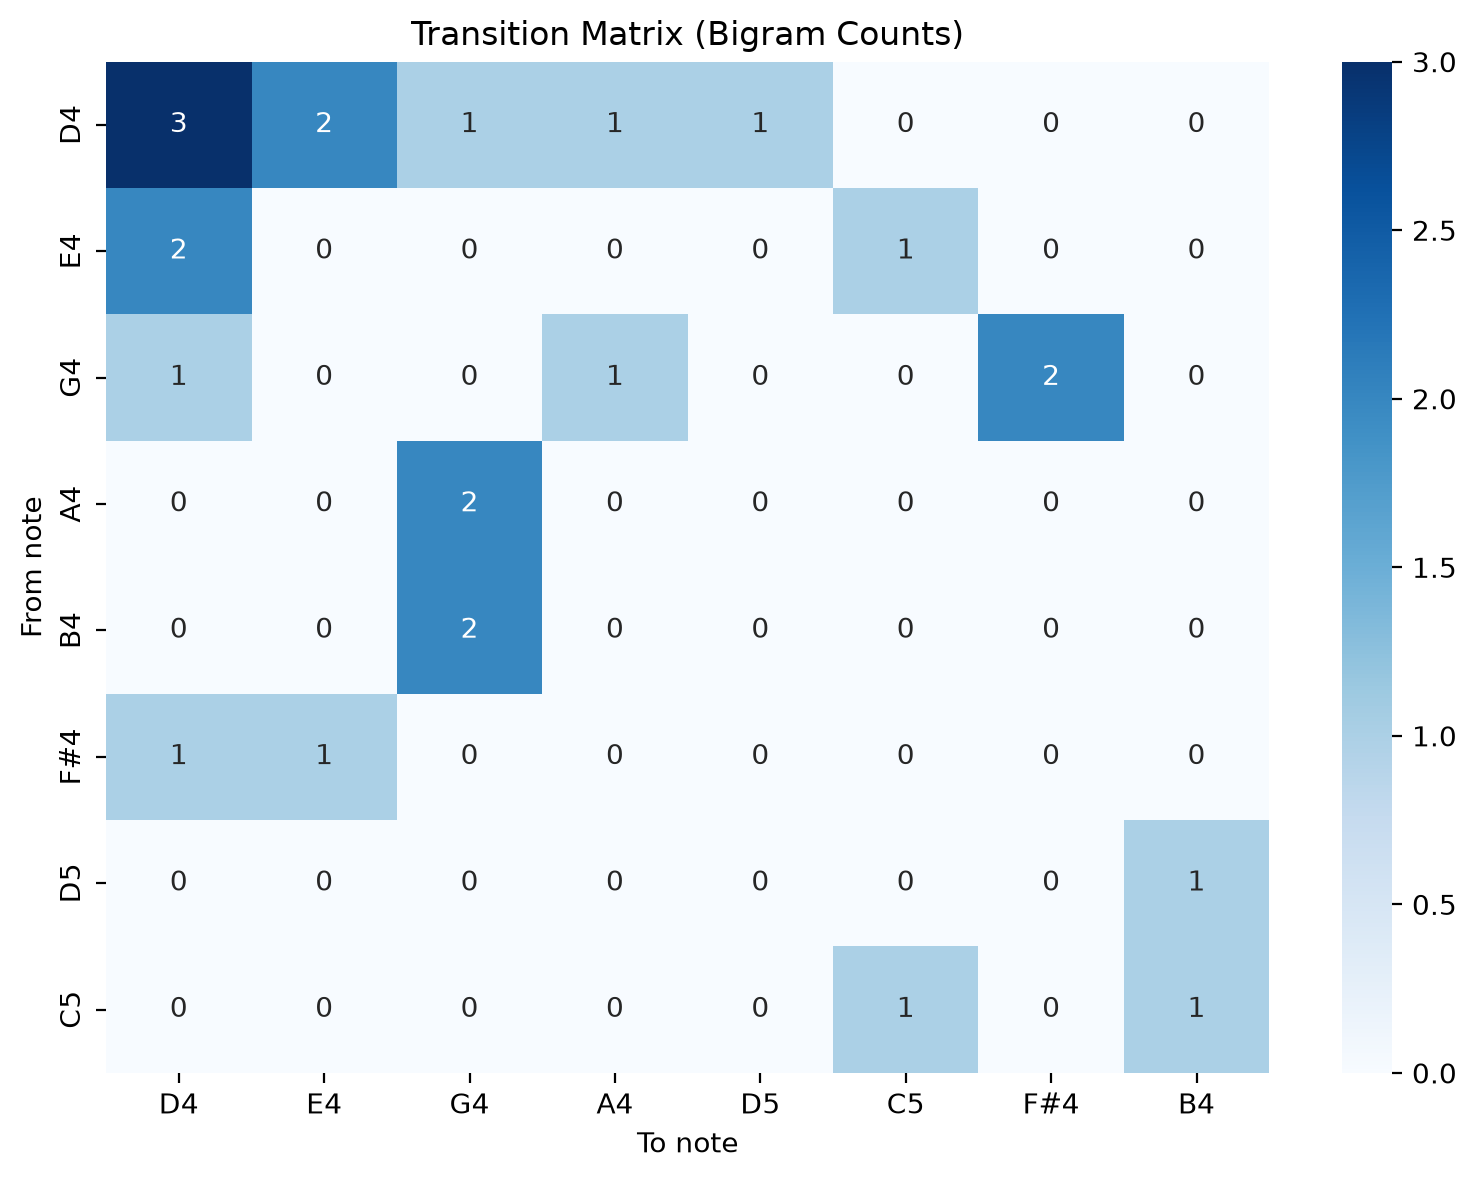

In [70]:
# Here we have functions that create a transition matrix from weighted n-grams and plot it as a heatmap.

def create_transition_matrix(weighted_ngrams):
    transition_matrix = {}

    # weighted_ngrams looks like: [(("C4", "D4"), 3), (("D4", "E4"), 2), ...]
    for ngram, count in weighted_ngrams:
        if len(ngram) < 2:
            continue

        from_note = ngram[0]
        to_note = ngram[1]

        # If this source note is new, create its inner dictionary.
        if from_note not in transition_matrix:
            transition_matrix[from_note] = {}

        # If this destination note is new for the source note, start at 0.
        if to_note not in transition_matrix[from_note]:
            transition_matrix[from_note][to_note] = 0

        transition_matrix[from_note][to_note] = transition_matrix[from_note][to_note] + count

    return transition_matrix

def plot_transition_matrix(transition_matrix):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Convert nested dictionary to a table (rows = from_note, columns = to_note).
    matrix_df = pd.DataFrame(transition_matrix).T.fillna(0).astype(int)

    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix_df, annot=True, fmt='d', cmap='Blues')
    plt.title('Transition Matrix (Bigram Counts)')
    plt.xlabel('To note')
    plt.ylabel('From note')
    plt.tight_layout()
    plt.show()

data = most_common_ngrams("../data/happy_birthday.krn", n=2)
matrix = create_transition_matrix(data)
plot_transition_matrix(matrix)

Let's take the functions above, but now add an 
option to display the transition matrix as percentages rather than raw counts.

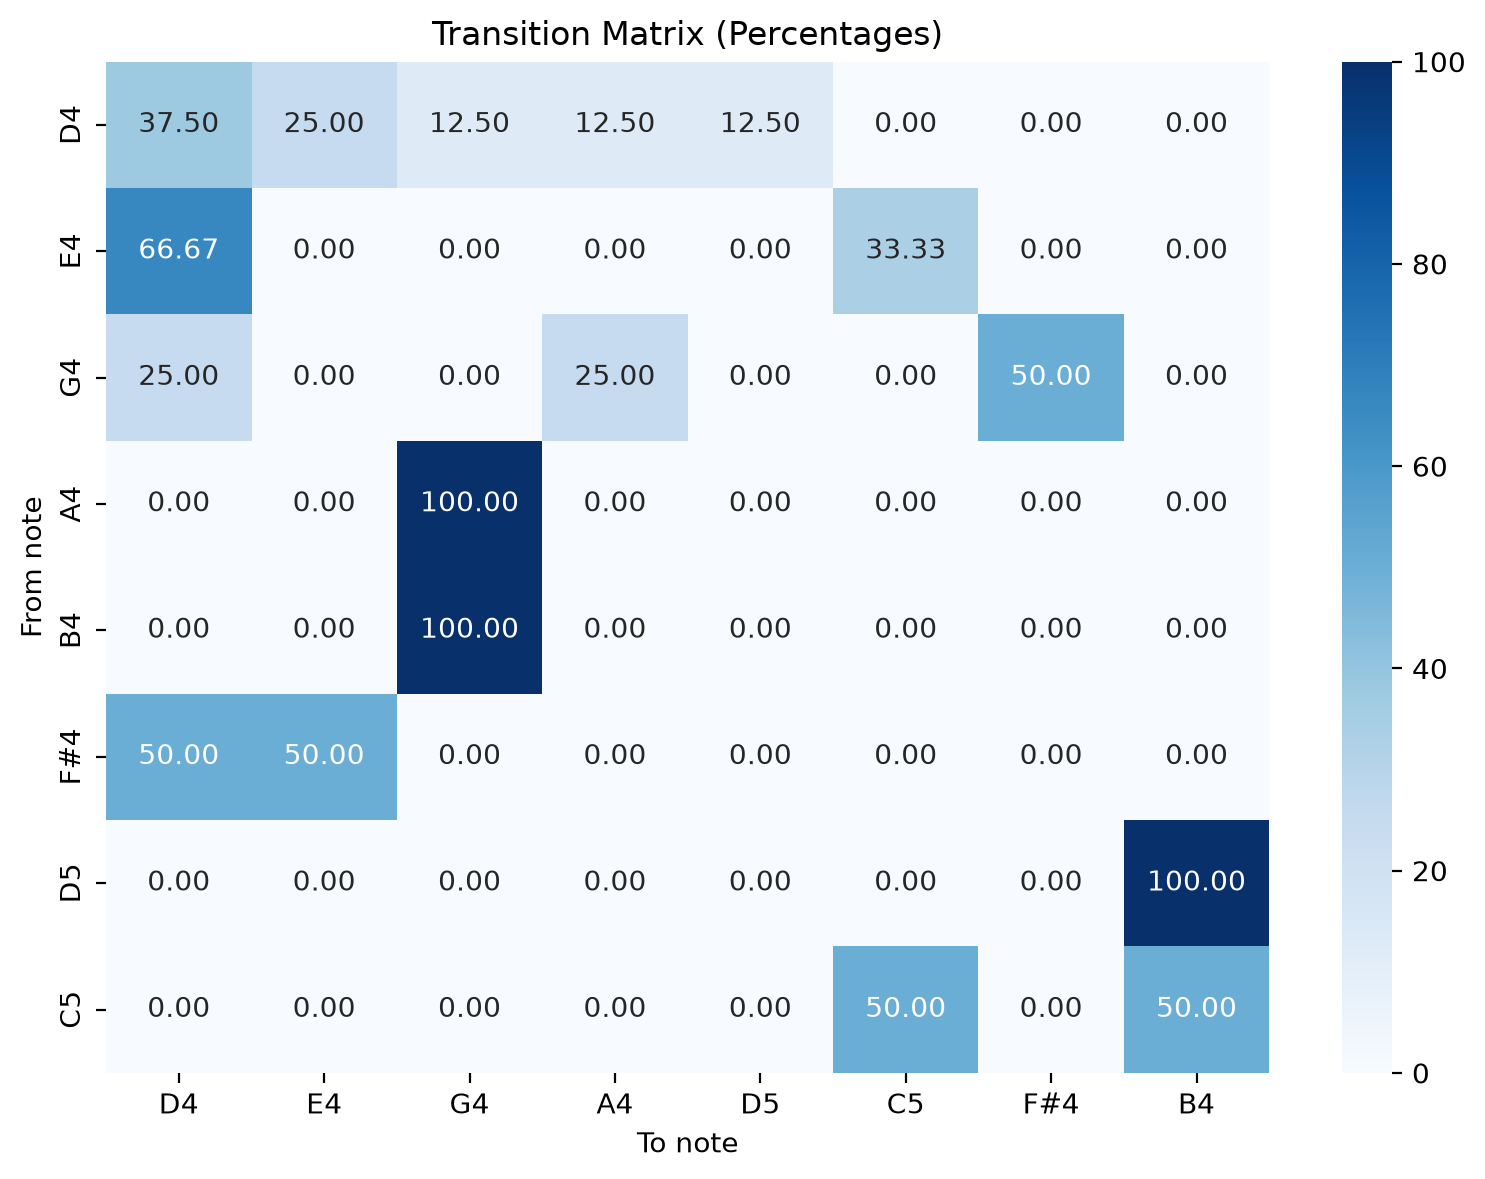

In [ ]:

def plot_transition_matrix(transition_matrix, as_percentages=False):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    matrix_df = pd.DataFrame(transition_matrix).T.fillna(0).astype(int)
    if as_percentages:
        matrix_df = matrix_df.div(matrix_df.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix_df, annot=True, fmt='.2f' if as_percentages else 'd', cmap='Blues')
    plt.title('Transition Matrix (Bigram Counts)' if not as_percentages else 'Transition Matrix (Percentages)')
    plt.xlabel('To note')
    plt.ylabel('From note')
    plt.tight_layout()
    plt.show()

data = most_common_ngrams("../data/happy_birthday.krn", n=2)
matrix = create_transition_matrix(data)
# plot_transition_matrix(matrix, as_percentages=False)
plot_transition_matrix(matrix, as_percentages=True)

### Plotting exercise
In the code below, take a piece, and plot it as raw counts and percentage. Discuss what insights the matrix might give you about the syntax of the piece. 

## Exercise 1: Raw counts vs percentages

Run the transition matrix on a Czech folksong (`../data/Essen/Czech/czech01.krn`)
and plot it both ways — raw counts and row percentages.

Then answer in a markdown cell below:
1. Which cell has the highest raw count? Which row has the most even 
   percentage distribution (i.e. the most unpredictable note)?
2. What does a row with one very dominant percentage tell you about 
   that note's melodic behavior in this piece?
3. Would you get a different answer if you used a different folksong 
   from the same folder? Run it on `czech02.krn` and check.

In [ ]:
#### your Exercise 1 code here...

# Transition Probabilities in an Entire Corpus

Let's look at two separate corpora now, comparing the transition probabilities in Charlie Parker and Dizzy Gillespie transcriptions.

Let's compare Charlie Parker compared to Dizzy Gillespie.
The code below defines shared helpers so we don't repeat parsing/mapping logic later.


In [ ]:


from music21 import converter
# we need glob so we can grab many files from a folder
from glob import glob
# Counter will count how often each bigram appears
from collections import Counter
# pandas is a nice library for clean tables!
import pandas as pd

# One shared label order we can reuse everywhere.
DEGREE_LABELS = ['1', 'b2', '2', 'b3', '3', '4', '#4', '5', 'b6', '6', 'b7', '7']

# Map 1..12 to chromatic scale-degree labels.
DEGREE_NAMES = {
    1: '1',
    2: 'b2',
    3: '2',
    4: 'b3',
    5: '3',
    6: '4',
    7: '#4',
    8: '5',
    9: 'b6',
    10: '6',
    11: 'b7',
    12: '7'
}

def extract_scale_degree_bigrams(file_list, corpus_name='Corpus'):
    """
    Return a Counter of chromatic scale-degree bigrams found in a list of files.
    Labels are: 1, b2, 2, b3, 3, 4, #4, 5, b6, 6, b7, 7.
    """

    # this list will hold every bigram from every piece
    all_bigrams = []
    # this list keeps track of files that fail to parse
    skipped_files = []

    # go piece by piece
    for file_path in file_list:
        try:
            # parse one file into a music21 score
            score = converter.parse(file_path)
        except Exception as exc:
            # if a file is malformed, skip it and keep moving
            skipped_files.append((file_path, str(exc)))
            continue

        # estimate key so degrees are relative to tonic
        estimated_key = score.analyze('key')
        tonic_pc = int(estimated_key.tonic.pitchClass)

        # Keep this simple: use score.pitches order to build adjacent-note bigrams.
        scale_degrees = []
        for p in score.pitches:
            pitch_pc = int(p.pitchClass)
            degree_number = ((pitch_pc - tonic_pc) % 12) + 1
            degree_label = DEGREE_NAMES[degree_number]
            scale_degrees.append(degree_label)

        piece_bigrams = list(zip(scale_degrees[:-1], scale_degrees[1:]))
        all_bigrams.extend(piece_bigrams)

    # quick transparency message if we skipped any files
    if skipped_files:
        print(f"{corpus_name}: skipped {len(skipped_files)} unreadable files.")

    # return counts + skipped files list
    return Counter(all_bigrams), skipped_files


#### note that you won't get anything out of running this cell; it's just defining functions!

In [127]:
### defining another function!
### this function takes a Counter of bigrams and returns 
### a nicely formatted table showing the top N bigrams.

def bigram_table(counter, corpus_name, top_n=15):
    #Turn a Counter into a readable top-N table.
    total = sum(counter.values())
    rows = []

    for (d1, d2), count in counter.most_common(top_n):
        percent = (count / total) * 100 if total else 0
        rows.append({
            'Corpus': corpus_name,
            'Bigram': f"{d1}->{d2}",
            'Count': count,
            'Percent': f"{percent:.2f}%"
        })

    return pd.DataFrame(rows)


In [96]:
### here we have a lot of print statements.
### specifically, we are printing out the number of files in each 
### corpus and the top bigrams for each musician.

# Collect files from each corpus
parker_files = sorted(glob('../data/charlie_parker/*.krn'))
dizzy_files = sorted(glob('../data/dizzy_gillespie/*.krn'))

print(f"Charlie Parker files: {len(parker_files)}")
print(f"Dizzy Gillespie files: {len(dizzy_files)}")

# 2) Count bigrams in each corpus
parker_bigrams, parker_skipped = extract_scale_degree_bigrams(parker_files, corpus_name='Charlie Parker')
dizzy_bigrams, dizzy_skipped = extract_scale_degree_bigrams(dizzy_files, corpus_name='Dizzy Gillespie')

# 3) Show top bigrams in each corpus
parker_top = bigram_table(parker_bigrams, 'Charlie Parker', top_n=15)
dizzy_top = bigram_table(dizzy_bigrams, 'Dizzy Gillespie', top_n=15)

print('\nTop Charlie Parker bigrams:')
print(parker_top.to_string(index=False))

print('\nTop Dizzy Gillespie bigrams:')
print(dizzy_top.to_string(index=False))


Charlie Parker files: 58
Dizzy Gillespie files: 13
Charlie Parker: skipped 15 unreadable files.
Dizzy Gillespie: skipped 12 unreadable files.

Top Charlie Parker bigrams:
        Corpus Bigram  Count Percent
Charlie Parker   2->1    738   3.23%
Charlie Parker   2->5    674   2.95%
Charlie Parker   5->1    653   2.86%
Charlie Parker   1->2    627   2.74%
Charlie Parker   1->7    560   2.45%
Charlie Parker   5->5    548   2.40%
Charlie Parker   5->4    518   2.27%
Charlie Parker   6->5    487   2.13%
Charlie Parker   3->2    451   1.97%
Charlie Parker   4->3    429   1.88%
Charlie Parker   7->1    417   1.82%
Charlie Parker   3->5    412   1.80%
Charlie Parker   5->6    395   1.73%
Charlie Parker   5->3    393   1.72%
Charlie Parker   1->5    380   1.66%

Top Dizzy Gillespie bigrams:
         Corpus Bigram  Count Percent
Dizzy Gillespie   5->4     20   4.28%
Dizzy Gillespie   2->1     18   3.85%
Dizzy Gillespie  b3->3     18   3.85%
Dizzy Gillespie   6->5     16   3.43%
Dizzy Gillespie  

In [128]:
#### and finally (!), this cell puts everything together and gives us the bigram analysis of common bigrams between the two corpora.
# 4) Show bigrams common to both corpora, ranked by combined frequency
common_bigrams = set(parker_bigrams) & set(dizzy_bigrams)
common_rows = []
for bg in common_bigrams:
    parker_count = parker_bigrams[bg]
    dizzy_count = dizzy_bigrams[bg]
    common_rows.append({
        'Bigram': f"{bg[0]}->{bg[1]}",
        'Parker Count': parker_count,
        'Dizzy Count': dizzy_count,
        'Combined Count': parker_count + dizzy_count
    })

common_df = pd.DataFrame(common_rows).sort_values('Combined Count', ascending=False).head(20)

print('\nMost common shared bigrams (top 20 by combined count):')
print(common_df.to_string(index=False))

# Optional: show skipped files for transparency
if parker_skipped or dizzy_skipped:
    print('\nSkipped files (first 5 shown):')
    all_skipped = parker_skipped + dizzy_skipped
    for file_path, message in all_skipped[:5]:
        print(f"- {file_path}: {message.splitlines()[0]}")


Most common shared bigrams (top 20 by combined count):
Bigram  Parker Count  Dizzy Count  Combined Count
  2->1           738           18             756
  2->5           674            1             675
  5->1           653            8             661
  1->2           627           14             641
  1->7           560            5             565
  5->5           548            7             555
  5->4           518           20             538
  6->5           487           16             503
  3->2           451           13             464
  4->3           429           13             442
  7->1           417           15             432
  3->5           412           14             426
  5->6           395            9             404
  5->3           393            4             397
  1->5           380            6             386
  1->1           368           15             383
  7->2           365           10             375
  1->6           361            8           

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns

# matrix builder (works for counts or row percentages).
def counter_to_degree_matrix(counter, value_type='counts'):
    # Step 1: start with a 12x12 table filled with zeros.
    matrix = {}
    for from_degree in DEGREE_LABELS:
        matrix[from_degree] = {}
        for to_degree in DEGREE_LABELS:
            matrix[from_degree][to_degree] = 0

    # Step 2: fill raw counts from the Counter.
    for bigram, count in counter.items():
        from_degree = bigram[0]
        to_degree = bigram[1]
        matrix[from_degree][to_degree] = count

    # Step 3: convert rows to percentages if requested.
    if value_type == 'percentages':
        for from_degree in DEGREE_LABELS:
            row_total = 0
            for to_degree in DEGREE_LABELS:
                row_total += matrix[from_degree][to_degree]

            if row_total > 0:
                for to_degree in DEGREE_LABELS:
                    matrix[from_degree][to_degree] = (matrix[from_degree][to_degree] / row_total) * 100

    # Step 4: return as DataFrame for easier plotting/printing.
    return pd.DataFrame(matrix).T


def plot_two_degree_matrices(left_matrix, right_matrix, left_name, right_name, value_type):
    # Make two side-by-side heatmaps.
    fig, axes = plt.subplots(1, 2, figsize=(22, 9), sharex=False, sharey=False)
    # Plot formatting changes depending on counts vs percentages.
    if value_type == 'counts':
        number_format = 'g'
        color_bar_label = 'Count'
    else:
        number_format = '.1f'
        color_bar_label = 'Percent'

    # Left corpus heatmap.
    sns.heatmap(
        left_matrix,
        annot=True,
        fmt=number_format,
        cmap='Blues',
        ax=axes[0],
        cbar_kws={'label': color_bar_label}
    )
    axes[0].set_title(left_name + ' (' + value_type + ', scale degrees)')
    axes[0].set_xlabel('To scale degree')
    axes[0].set_ylabel('From scale degree')

    # Right corpus heatmap.
    sns.heatmap(
        right_matrix,
        annot=True,
        fmt=number_format,
        cmap='Blues',
        ax=axes[1],
        cbar_kws={'label': color_bar_label}
    )
    axes[1].set_title(right_name + ' (' + value_type + ', scale degrees)')
    axes[1].set_xlabel('To scale degree')
    axes[1].set_ylabel('From scale degree')

    plt.tight_layout()
    plt.show()


English files: 4
Czech files: 43


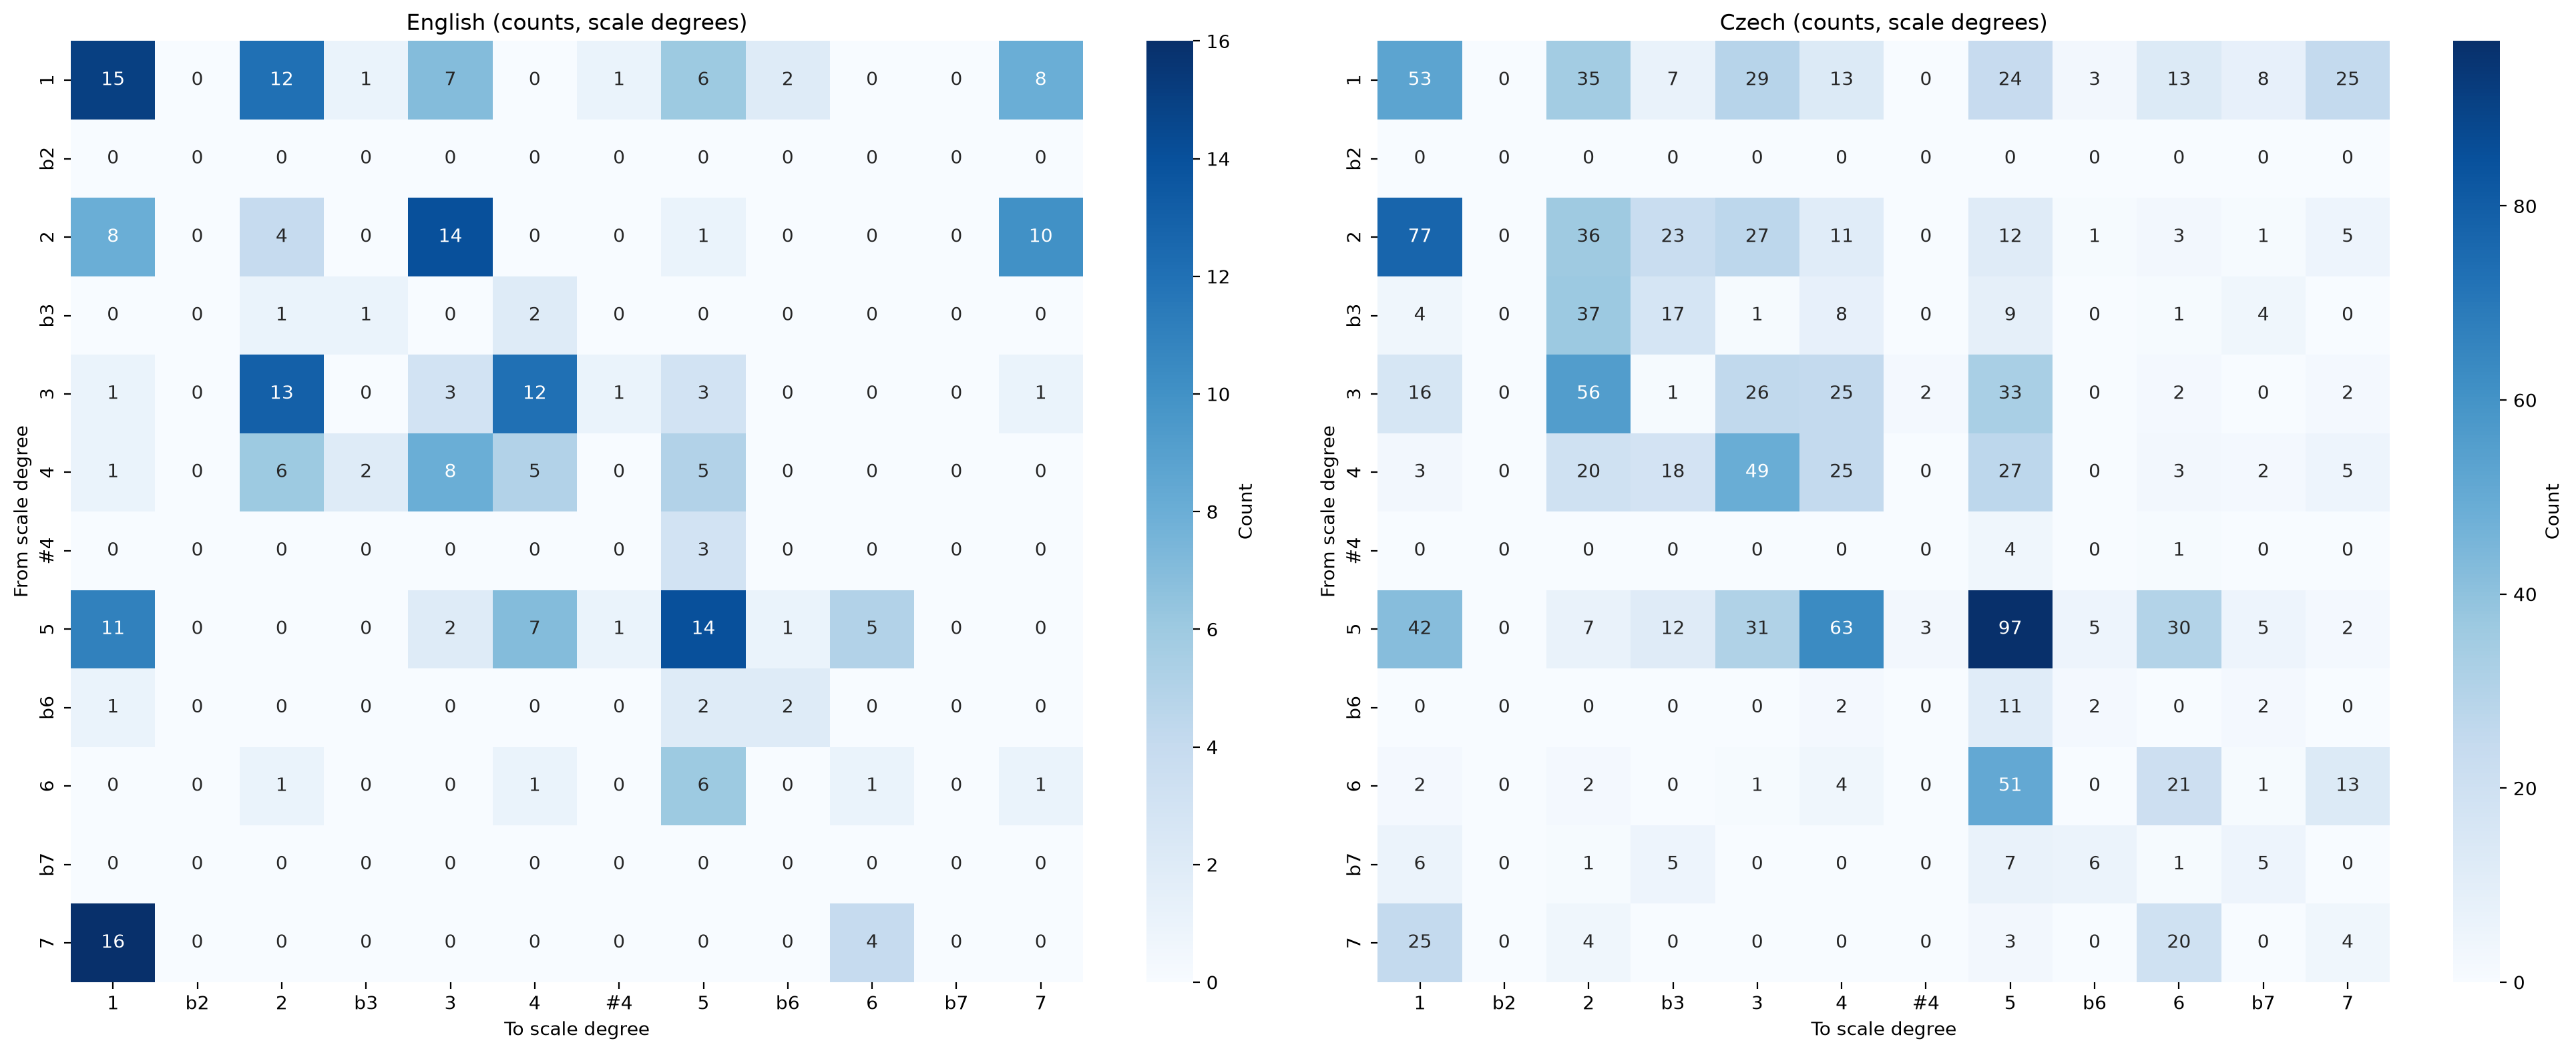

(     1  b2   2  b3   3   4  #4   5  b6  6  b7   7
 1   15   0  12   1   7   0   1   6   2  0   0   8
 b2   0   0   0   0   0   0   0   0   0  0   0   0
 2    8   0   4   0  14   0   0   1   0  0   0  10
 b3   0   0   1   1   0   2   0   0   0  0   0   0
 3    1   0  13   0   3  12   1   3   0  0   0   1
 4    1   0   6   2   8   5   0   5   0  0   0   0
 #4   0   0   0   0   0   0   0   3   0  0   0   0
 5   11   0   0   0   2   7   1  14   1  5   0   0
 b6   1   0   0   0   0   0   0   2   2  0   0   0
 6    0   0   1   0   0   1   0   6   0  1   0   1
 b7   0   0   0   0   0   0   0   0   0  0   0   0
 7   16   0   0   0   0   0   0   0   0  4   0   0,
      1  b2   2  b3   3   4  #4   5  b6   6  b7   7
 1   53   0  35   7  29  13   0  24   3  13   8  25
 b2   0   0   0   0   0   0   0   0   0   0   0   0
 2   77   0  36  23  27  11   0  12   1   3   1   5
 b3   4   0  37  17   1   8   0   9   0   1   4   0
 3   16   0  56   1  26  25   2  33   0   2   0   2
 4    3   0  20  18  49 

In [131]:

def compare_two_corpora_bigrams(
    left_files,
    right_files,
    left_name='Corpus A',
    right_name='Corpus B',
    value_type='counts',
    top_n=None
    ):
    """
    Build key-relative chromatic SCALE-DEGREE bigram matrices for two corpora
    and show them side by side.


    Degree labels used:
    1, b2, 2, b3, 3, 4, #4, 5, b6, 6, b7, 7
    """

    # Step 1: make sure the mode is valid.
    if value_type != 'counts' and value_type != 'percentages':
        raise ValueError("value_type must be 'counts' or 'percentages'")

    # Step 2: get bigram counters for both corpora using the shared extractor above.
    left_counter, _ = extract_scale_degree_bigrams(
        left_files,
        corpus_name=left_name
    )
    right_counter, _ = extract_scale_degree_bigrams(
        right_files,
        corpus_name=right_name
    )

    # Step 3 (optional): keep only top N bigrams if requested.
    if top_n is not None:
        left_top_counter = Counter()
        for bigram, count in left_counter.most_common(top_n):
            left_top_counter[bigram] = count
        left_counter = left_top_counter

        right_top_counter = Counter()
        for bigram, count in right_counter.most_common(top_n):
            right_top_counter[bigram] = count
        right_counter = right_top_counter

    # Step 4: turn counters into 12x12 matrices.
    left_matrix = counter_to_degree_matrix(left_counter, value_type=value_type)
    right_matrix = counter_to_degree_matrix(right_counter, value_type=value_type)


    # Step 5: plot both matrices side by side.
    plot_two_degree_matrices(left_matrix, right_matrix, left_name, right_name, value_type)

    # Step 6: return outputs in case we want to reuse them later.
    return left_matrix, right_matrix


### now let's run it!

# File lists for each artist corpus
english = sorted(glob('../data/Essen/England/*.krn'))
czech = sorted(glob('../data/Essen/Czech/*.krn'))

print('English files:', len(english))
print('Czech files:', len(czech))

# Example call (raw counts, scale-degree representation).
compare_two_corpora_bigrams(
    english,
    czech,
    left_name='English',
    right_name='Czech',
    value_type='counts',
    top_n=None
)

Charlie Parker: skipped 15 unreadable files.
Dizzy Gillespie: skipped 12 unreadable files.

----- Charlie Parker scale-degree matrix (percentages) -----
            1        b2          2        b3          3          4        #4  \
1   10.779145  3.309900  18.365554  3.778559   9.138840   6.033978  1.552431   
b2  27.900147  4.405286  19.530103  3.817915  10.132159   2.643172  2.055800   
2   24.141315  7.687275   8.930324  6.902192   9.224730   7.425581  2.224403   
b3  19.028340  4.655870  22.773279  8.299595  17.004049   6.072874  2.732794   
3    9.472196  2.403393  21.253534  6.079171   5.702168  14.750236  4.759661   
4    7.275542  2.734778  13.003096  7.894737  22.136223   9.133127  5.417957   
#4   5.695509  1.642935   7.557503  5.805038  14.129244  13.691128  4.600219   
5   17.558483  0.833557   6.453348  2.715784  10.567357  13.928475  7.663350   
b6   5.869565  2.500000   1.847826  1.304348   5.000000  13.260870  6.847826   
6   12.729718  0.627521  14.701927  1.568803   

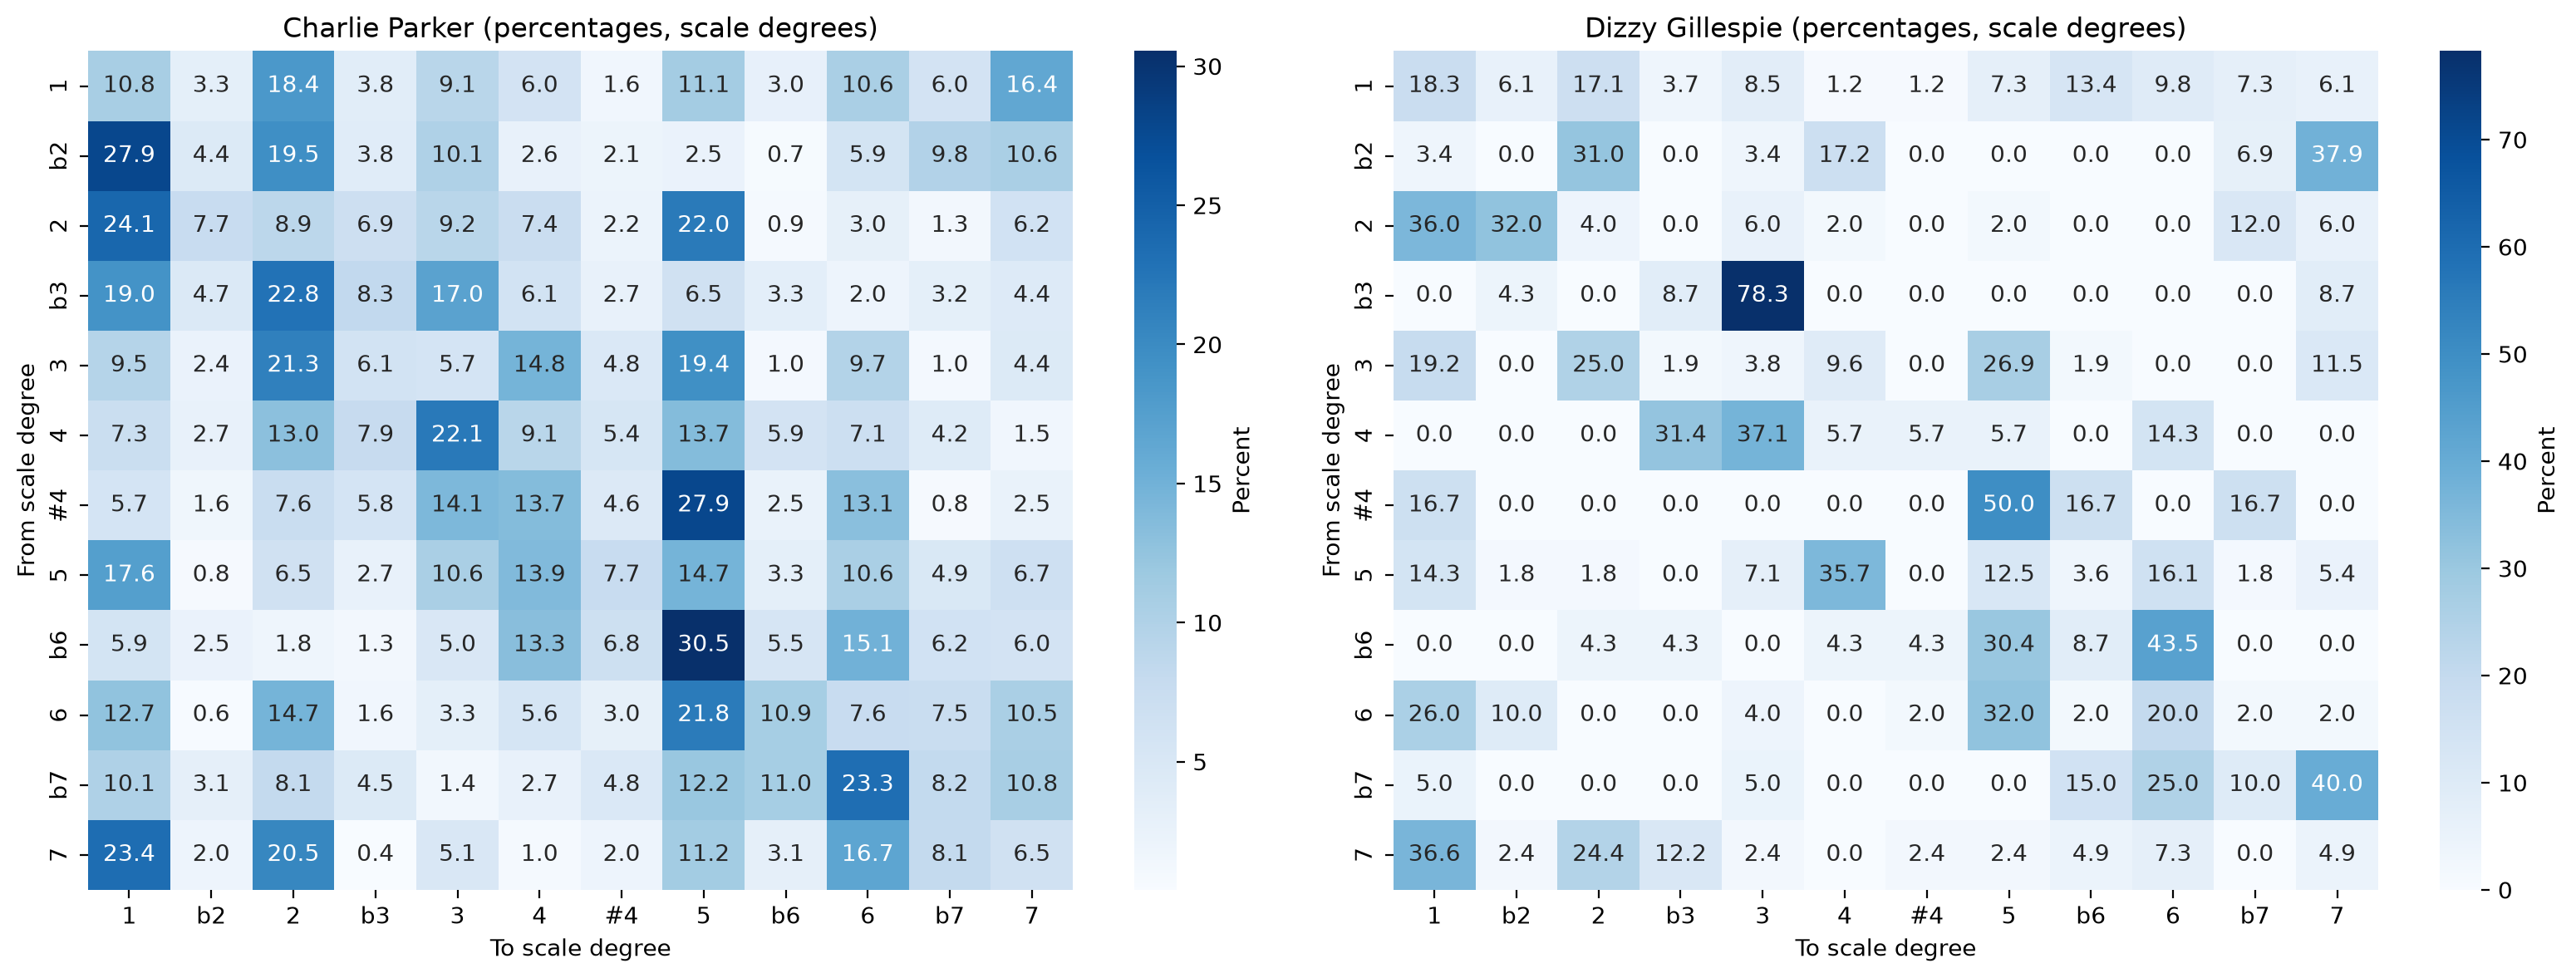

(            1        b2          2        b3          3          4        #4  \
 1   10.779145  3.309900  18.365554  3.778559   9.138840   6.033978  1.552431   
 b2  27.900147  4.405286  19.530103  3.817915  10.132159   2.643172  2.055800   
 2   24.141315  7.687275   8.930324  6.902192   9.224730   7.425581  2.224403   
 b3  19.028340  4.655870  22.773279  8.299595  17.004049   6.072874  2.732794   
 3    9.472196  2.403393  21.253534  6.079171   5.702168  14.750236  4.759661   
 4    7.275542  2.734778  13.003096  7.894737  22.136223   9.133127  5.417957   
 #4   5.695509  1.642935   7.557503  5.805038  14.129244  13.691128  4.600219   
 5   17.558483  0.833557   6.453348  2.715784  10.567357  13.928475  7.663350   
 b6   5.869565  2.500000   1.847826  1.304348   5.000000  13.260870  6.847826   
 6   12.729718  0.627521  14.701927  1.568803   3.316898   5.602869  3.047961   
 b7  10.064044  3.110704   8.051235  4.483074   1.372370   2.653248  4.757548   
 7   23.426966  2.022472  20

In [109]:
# Run the same comparison, but now as row percentages (chromatic).
compare_two_corpora_bigrams(
    parker_files,
    dizzy_files,
    left_name='Charlie Parker',
    right_name='Dizzy Gillespie',
    value_type='percentages',
    top_n=None
)

## Exercise 2: A third corpus

The notebook compared Parker and Dizzy. Now add a third corpus of your choice
from the Essen collection (e.g. England, Polska, Rossiya).

Use `compare_two_corpora_bigrams()` to compare it against one of the jazz corpora.

Then answer:
1. Which bigrams appear in both the jazz corpus and the folk corpus? 
   Are they musically surprising or expected?
2. What does the comparison tell you about the limits of scale-degree bigrams 
   as a cross-repertoire similarity measure?

English files: 4
Czech files: 43


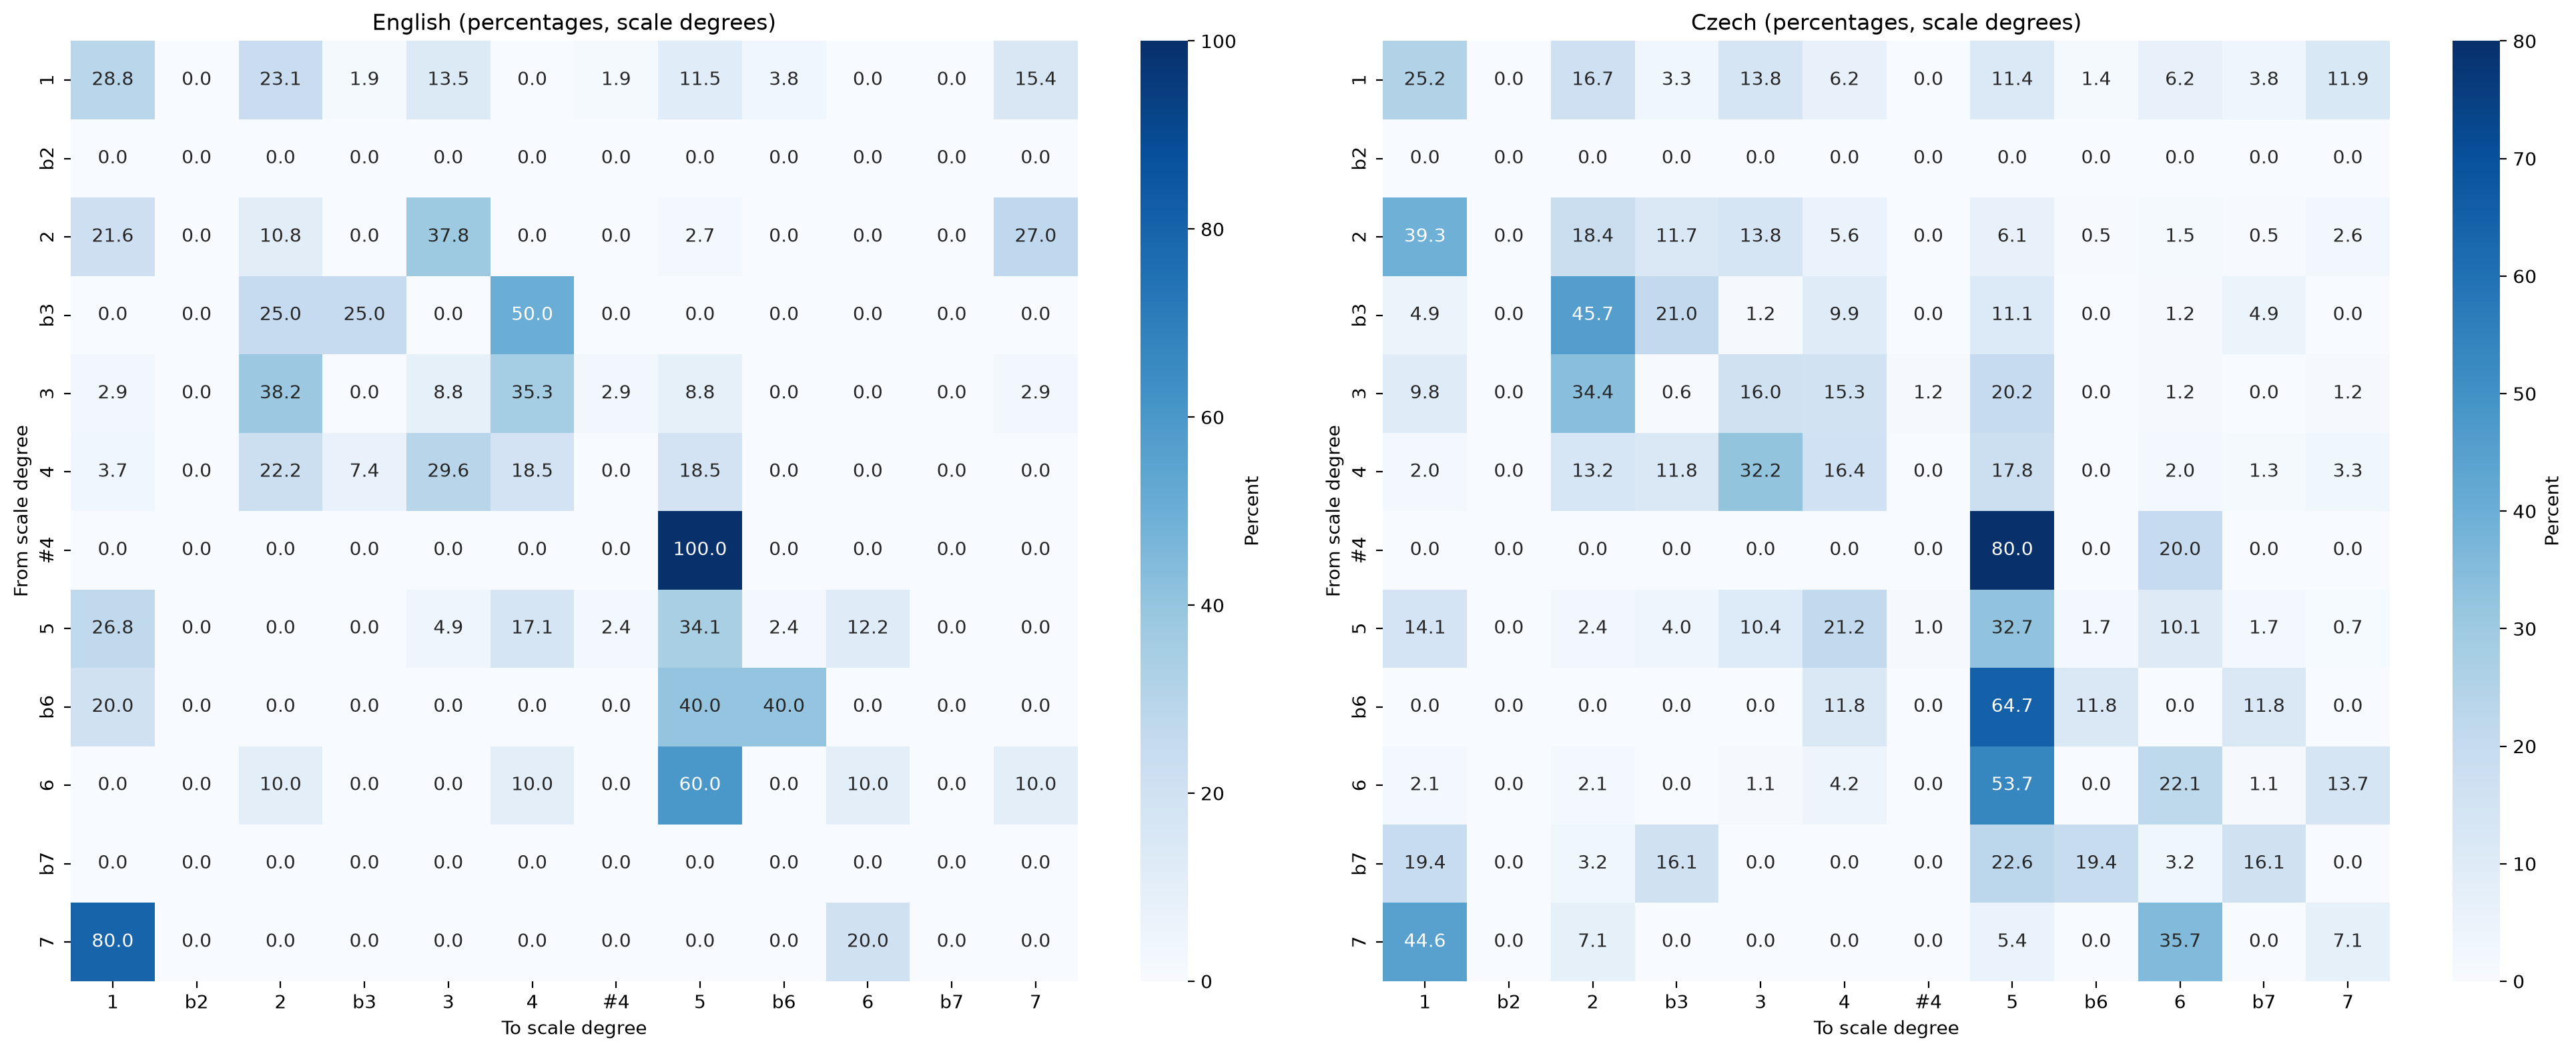

(            1   b2          2         b3          3          4        #4  \
 1   28.846154  0.0  23.076923   1.923077  13.461538   0.000000  1.923077   
 b2   0.000000  0.0   0.000000   0.000000   0.000000   0.000000  0.000000   
 2   21.621622  0.0  10.810811   0.000000  37.837838   0.000000  0.000000   
 b3   0.000000  0.0  25.000000  25.000000   0.000000  50.000000  0.000000   
 3    2.941176  0.0  38.235294   0.000000   8.823529  35.294118  2.941176   
 4    3.703704  0.0  22.222222   7.407407  29.629630  18.518519  0.000000   
 #4   0.000000  0.0   0.000000   0.000000   0.000000   0.000000  0.000000   
 5   26.829268  0.0   0.000000   0.000000   4.878049  17.073171  2.439024   
 b6  20.000000  0.0   0.000000   0.000000   0.000000   0.000000  0.000000   
 6    0.000000  0.0  10.000000   0.000000   0.000000  10.000000  0.000000   
 b7   0.000000  0.0   0.000000   0.000000   0.000000   0.000000  0.000000   
 7   80.000000  0.0   0.000000   0.000000   0.000000   0.000000  0.000000   

In [132]:
# File lists for each artist corpus
english = sorted(glob('../data/Essen/England/*.krn'))
czech = sorted(glob('../data/Essen/Czech/*.krn'))

print('English files:', len(english))
print('Czech files:', len(czech))

# Example call (raw counts, scale-degree representation).
compare_two_corpora_bigrams(
    english,
    czech,
    left_name='English',
    right_name='Czech',
    value_type='percentages',
    top_n=None
)

## Bigrams with Beat Strength

So far, we have looked at bigrams as note-to-note pitch patterns.
Now we will keep that same idea, but focus only on beat strength.

In this section, we use music21's `beatStrength` to filter notes before counting bigrams.
That means we can compare bigrams from:
- all notes
- strong beats
- medium-strength beats
- weak beats

For now, we are staying with beat-strength filtering only, so the workflow stays simple and consistent for everyone.

music21 has a nice beatStrength tool that can be useful for filtering things out.

In [169]:
def top_bigrams_df(counter, corpus_name, beat_filter='all', top_n=10):
    """Turn a Counter into a clean top-N table for display."""

    total = sum(counter.values())
    rows = []

    for (d1, d2), count in counter.most_common(top_n):
        percent = (count / total) * 100 if total else 0
        rows.append({
            'Corpus': corpus_name,
            'Filter': beat_filter,
            'Bigram': f"{d1}->{d2}",
            'Count': count,
            'Percent': f"{percent:.2f}%"
        })

    return pd.DataFrame(rows)



In [170]:

# Beginner-friendly beat-strength filters.
beat_filters = [
    'all',
    'strong_>=0.75',
    'medium_0.5_to_<0.75',
    'weak_<0.5',
]


In [171]:
# Load .krn files for each corpus (so this section works on its own).

# Step 1: get all English .krn files from the folder.
english = sorted(glob('../data/Essen/England/*.krn'))

# Step 2: get all Czech .krn files from the folder.
czech = sorted(glob('../data/Essen/Czech/*.krn'))

# Step 3: print how many files we found.
print('English files:', len(english))
print('Czech files:', len(czech))

English files: 4
Czech files: 43


In [172]:
# One corpus + one beat-strength filter (beginner version)

# Step 1: pick one corpus.
selected_files = english
selected_corpus_name = 'English'   # change to 'Czech' and czech files if you want

# Step 2: pick one beat-strength filter.
# You can use short names: 'strong', 'medium', 'weak'
selected_filter = 'strong'   # also works: 'all', 'strong_>=0.75', 'medium_0.5_to_<0.75', 'weak_<0.5'

# Step 3: extract bigrams for this one corpus and this one filter.
selected_counter, skipped_files = extract_scale_degree_bigrams_by_beatstrength(
    selected_files,
    corpus_name=selected_corpus_name,
    strength_filter=selected_filter
)

# Step 4: build a top-10 table.
selected_table = top_bigrams_df(
    selected_counter,
    corpus_name=selected_corpus_name,
    beat_filter=selected_filter,
    top_n=10
)

# Step 5: show simple output.
print('Corpus:', selected_corpus_name)
print('Filter:', selected_filter)
print('Files skipped:', len(skipped_files))
display(selected_table)

Corpus: English
Filter: strong
Files skipped: 0


,Corpus,Filter,Bigram,Count,Percent
0,English,strong,1->1,9,12.68%
1,English,strong,3->2,6,8.45%
2,English,strong,1->5,6,8.45%
3,English,strong,5->1,5,7.04%
4,English,strong,1->7,4,5.63%
5,English,strong,2->1,4,5.63%
6,English,strong,4->3,4,5.63%
7,English,strong,1->3,4,5.63%
8,English,strong,2->2,3,4.23%
9,English,strong,5->5,3,4.23%


In [150]:
# We run the SAME workflow once for each beat-strength group.
# This is intentionally repetitive so beginners can follow every step.
for beat_strength_group in beat_filters:
    # ------------------------------------------------------------
    # Step 1: print a clear header so we know which filter we are in.
    # ------------------------------------------------------------
    print("\n" + "=" * 80)
    print("Beat-strength filter:", beat_strength_group)
    print("=" * 80)

    # ------------------------------------------------------------
    # Step 2: collect bigrams from the English corpus for this filter.
    # ------------------------------------------------------------
    english_counter, _ = extract_scale_degree_bigrams_by_beatstrength(
        english,
        corpus_name='English',
        strength_filter=beat_strength_group
    )

    # ------------------------------------------------------------
    # Step 3: collect bigrams from the Czech corpus for this filter.
    # ------------------------------------------------------------
    czech_counter, _ = extract_scale_degree_bigrams_by_beatstrength(
        czech,
        corpus_name='Czech',
        strength_filter=beat_strength_group
    )

    # ------------------------------------------------------------
    # Step 4: turn the counters into clean top-10 tables.
    # ------------------------------------------------------------
    english_table = top_bigrams_df(
        english_counter,
        corpus_name='English',
        beat_filter=beat_strength_group,
        top_n=10
    )

    czech_table = top_bigrams_df(
        czech_counter,
        corpus_name='Czech',
        beat_filter=beat_strength_group,
        top_n=10
    )

    # ------------------------------------------------------------
    # Step 5: show both tables in the notebook output.
    # ------------------------------------------------------------
    display(english_table)
    display(czech_table)


Beat-strength filter: all


,Corpus,Filter,Bigram,Count,Percent
0,English,all,7->1,16,6.87%
1,English,all,1->1,15,6.44%
2,English,all,2->3,14,6.01%
3,English,all,5->5,14,6.01%
4,English,all,3->2,13,5.58%
5,English,all,1->2,12,5.15%
6,English,all,3->4,12,5.15%
7,English,all,5->1,11,4.72%
8,English,all,2->7,10,4.29%
9,English,all,1->7,8,3.43%


,Corpus,Filter,Bigram,Count,Percent
0,Czech,all,5->5,97,7.44%
1,Czech,all,2->1,77,5.91%
2,Czech,all,5->4,63,4.83%
3,Czech,all,3->2,56,4.30%
4,Czech,all,1->1,53,4.07%
5,Czech,all,6->5,51,3.91%
6,Czech,all,4->3,49,3.76%
7,Czech,all,5->1,42,3.22%
8,Czech,all,b3->2,37,2.84%
9,Czech,all,2->2,36,2.76%



Beat-strength filter: strong_>=0.75


,Corpus,Filter,Bigram,Count,Percent
0,English,strong_>=0.75,1->1,9,12.68%
1,English,strong_>=0.75,3->2,6,8.45%
2,English,strong_>=0.75,1->5,6,8.45%
3,English,strong_>=0.75,5->1,5,7.04%
4,English,strong_>=0.75,1->7,4,5.63%
5,English,strong_>=0.75,2->1,4,5.63%
6,English,strong_>=0.75,4->3,4,5.63%
7,English,strong_>=0.75,1->3,4,5.63%
8,English,strong_>=0.75,2->2,3,4.23%
9,English,strong_>=0.75,5->5,3,4.23%


...

,Corpus,Filter,Bigram,Count,Percent
0,English,medium_0.5_to_<0.75,2->3,9,11.69%
1,English,medium_0.5_to_<0.75,3->4,7,9.09%
2,English,medium_0.5_to_<0.75,4->3,5,6.49%
3,English,medium_0.5_to_<0.75,3->7,5,6.49%
4,English,medium_0.5_to_<0.75,5->2,5,6.49%
5,English,medium_0.5_to_<0.75,1->1,4,5.19%
6,English,medium_0.5_to_<0.75,1->2,3,3.90%
7,English,medium_0.5_to_<0.75,7->5,3,3.90%
8,English,medium_0.5_to_<0.75,1->5,3,3.90%
9,English,medium_0.5_to_<0.75,3->6,3,3.90%


,Corpus,Filter,Bigram,Count,Percent
0,Czech,medium_0.5_to_<0.75,5->2,18,6.25%
1,Czech,medium_0.5_to_<0.75,5->3,17,5.90%
2,Czech,medium_0.5_to_<0.75,5->5,14,4.86%
3,Czech,medium_0.5_to_<0.75,2->5,11,3.82%
4,Czech,medium_0.5_to_<0.75,2->1,11,3.82%
5,Czech,medium_0.5_to_<0.75,2->2,10,3.47%
6,Czech,medium_0.5_to_<0.75,3->3,10,3.47%
7,Czech,medium_0.5_to_<0.75,1->5,10,3.47%
8,Czech,medium_0.5_to_<0.75,3->5,9,3.12%
9,Czech,medium_0.5_to_<0.75,4->5,9,3.12%



Beat-strength filter: weak_<0.5


,Corpus,Filter,Bigram,Count,Percent
0,English,weak_<0.5,5->5,5,6.49%
1,English,weak_<0.5,5->7,5,6.49%
2,English,weak_<0.5,7->5,5,6.49%
3,English,weak_<0.5,2->1,4,5.19%
4,English,weak_<0.5,1->4,4,5.19%
5,English,weak_<0.5,4->2,4,5.19%
6,English,weak_<0.5,1->2,3,3.90%
7,English,weak_<0.5,1->1,3,3.90%
8,English,weak_<0.5,2->7,3,3.90%
9,English,weak_<0.5,4->1,2,2.60%


,Corpus,Filter,Bigram,Count,Percent
0,Czech,weak_<0.5,5->5,35,6.36%
1,Czech,weak_<0.5,3->1,22,4.00%
2,Czech,weak_<0.5,2->2,21,3.82%
3,Czech,weak_<0.5,5->3,20,3.64%
4,Czech,weak_<0.5,6->5,19,3.45%
5,Czech,weak_<0.5,5->1,17,3.09%
6,Czech,weak_<0.5,1->6,17,3.09%
7,Czech,weak_<0.5,1->3,16,2.91%
8,Czech,weak_<0.5,3->5,16,2.91%
9,Czech,weak_<0.5,1->1,16,2.91%


## Exercise 3: Beat strength and melodic tendency

Before running the code, write a prediction in the cell below:
- Do you expect the most common bigrams on downbeats to be the same as 
the most common bigrams on weak beats, or different? Why?

- After you've made your prediction, run the beat-strength filter on the English Essen folksongs 
with `beat_filter='all'`, `'strong'`, and `'downbeat'`.

- Compare the top-5 bigrams under each filter. Was your prediction correct?
If the results surprised you, what does that tell you about where 
melodic structure is "located" in these folksongs?

In [ ]:
### your Exercise 3 code here...



In [163]:
from glob import glob
from music21 import converter
import pandas as pd

# Build a simple interval dataset from two .krn folders.
rows = []
streams = {}

corpora = [
    ('English', '../data/Essen/England/*.krn'),
    ('Czech', '../data/Essen/Czech/*.krn'),
]

for mode_name, pattern in corpora:
    file_list = sorted(glob(pattern))

    for file_path in file_list:
        try:
            score = converter.parse(file_path)
            streams[file_path] = score

            # Grab a simple melodic pitch sequence (first pitch if chord).
            midi_values = []
            for element in score.recurse().notes:
                if element.isChord:
                    midi_values.append(int(element.pitches[0].midi))
                else:
                    midi_values.append(int(element.pitch.midi))

            # Turn pitch sequence into consecutive melodic intervals.
            intervals = []
            for a, b in zip(midi_values, midi_values[1:]):
                intervals.append(b - a)

            tune_id = file_path.split('/')[-1].replace('.krn', '')
            rows.append({
                'tune_id': tune_id,
                'mode': mode_name,
                'intervals': intervals,
                'source_file': file_path,
            })
        except Exception:
            continue

df = pd.DataFrame(rows)
print(f'{len(df)} tunes loaded with interval lists')

47 tunes loaded with interval lists


# Interval Bigrams
Scale-degree bigrams describe *what* follows what. Interval bigrams describe *how far*.


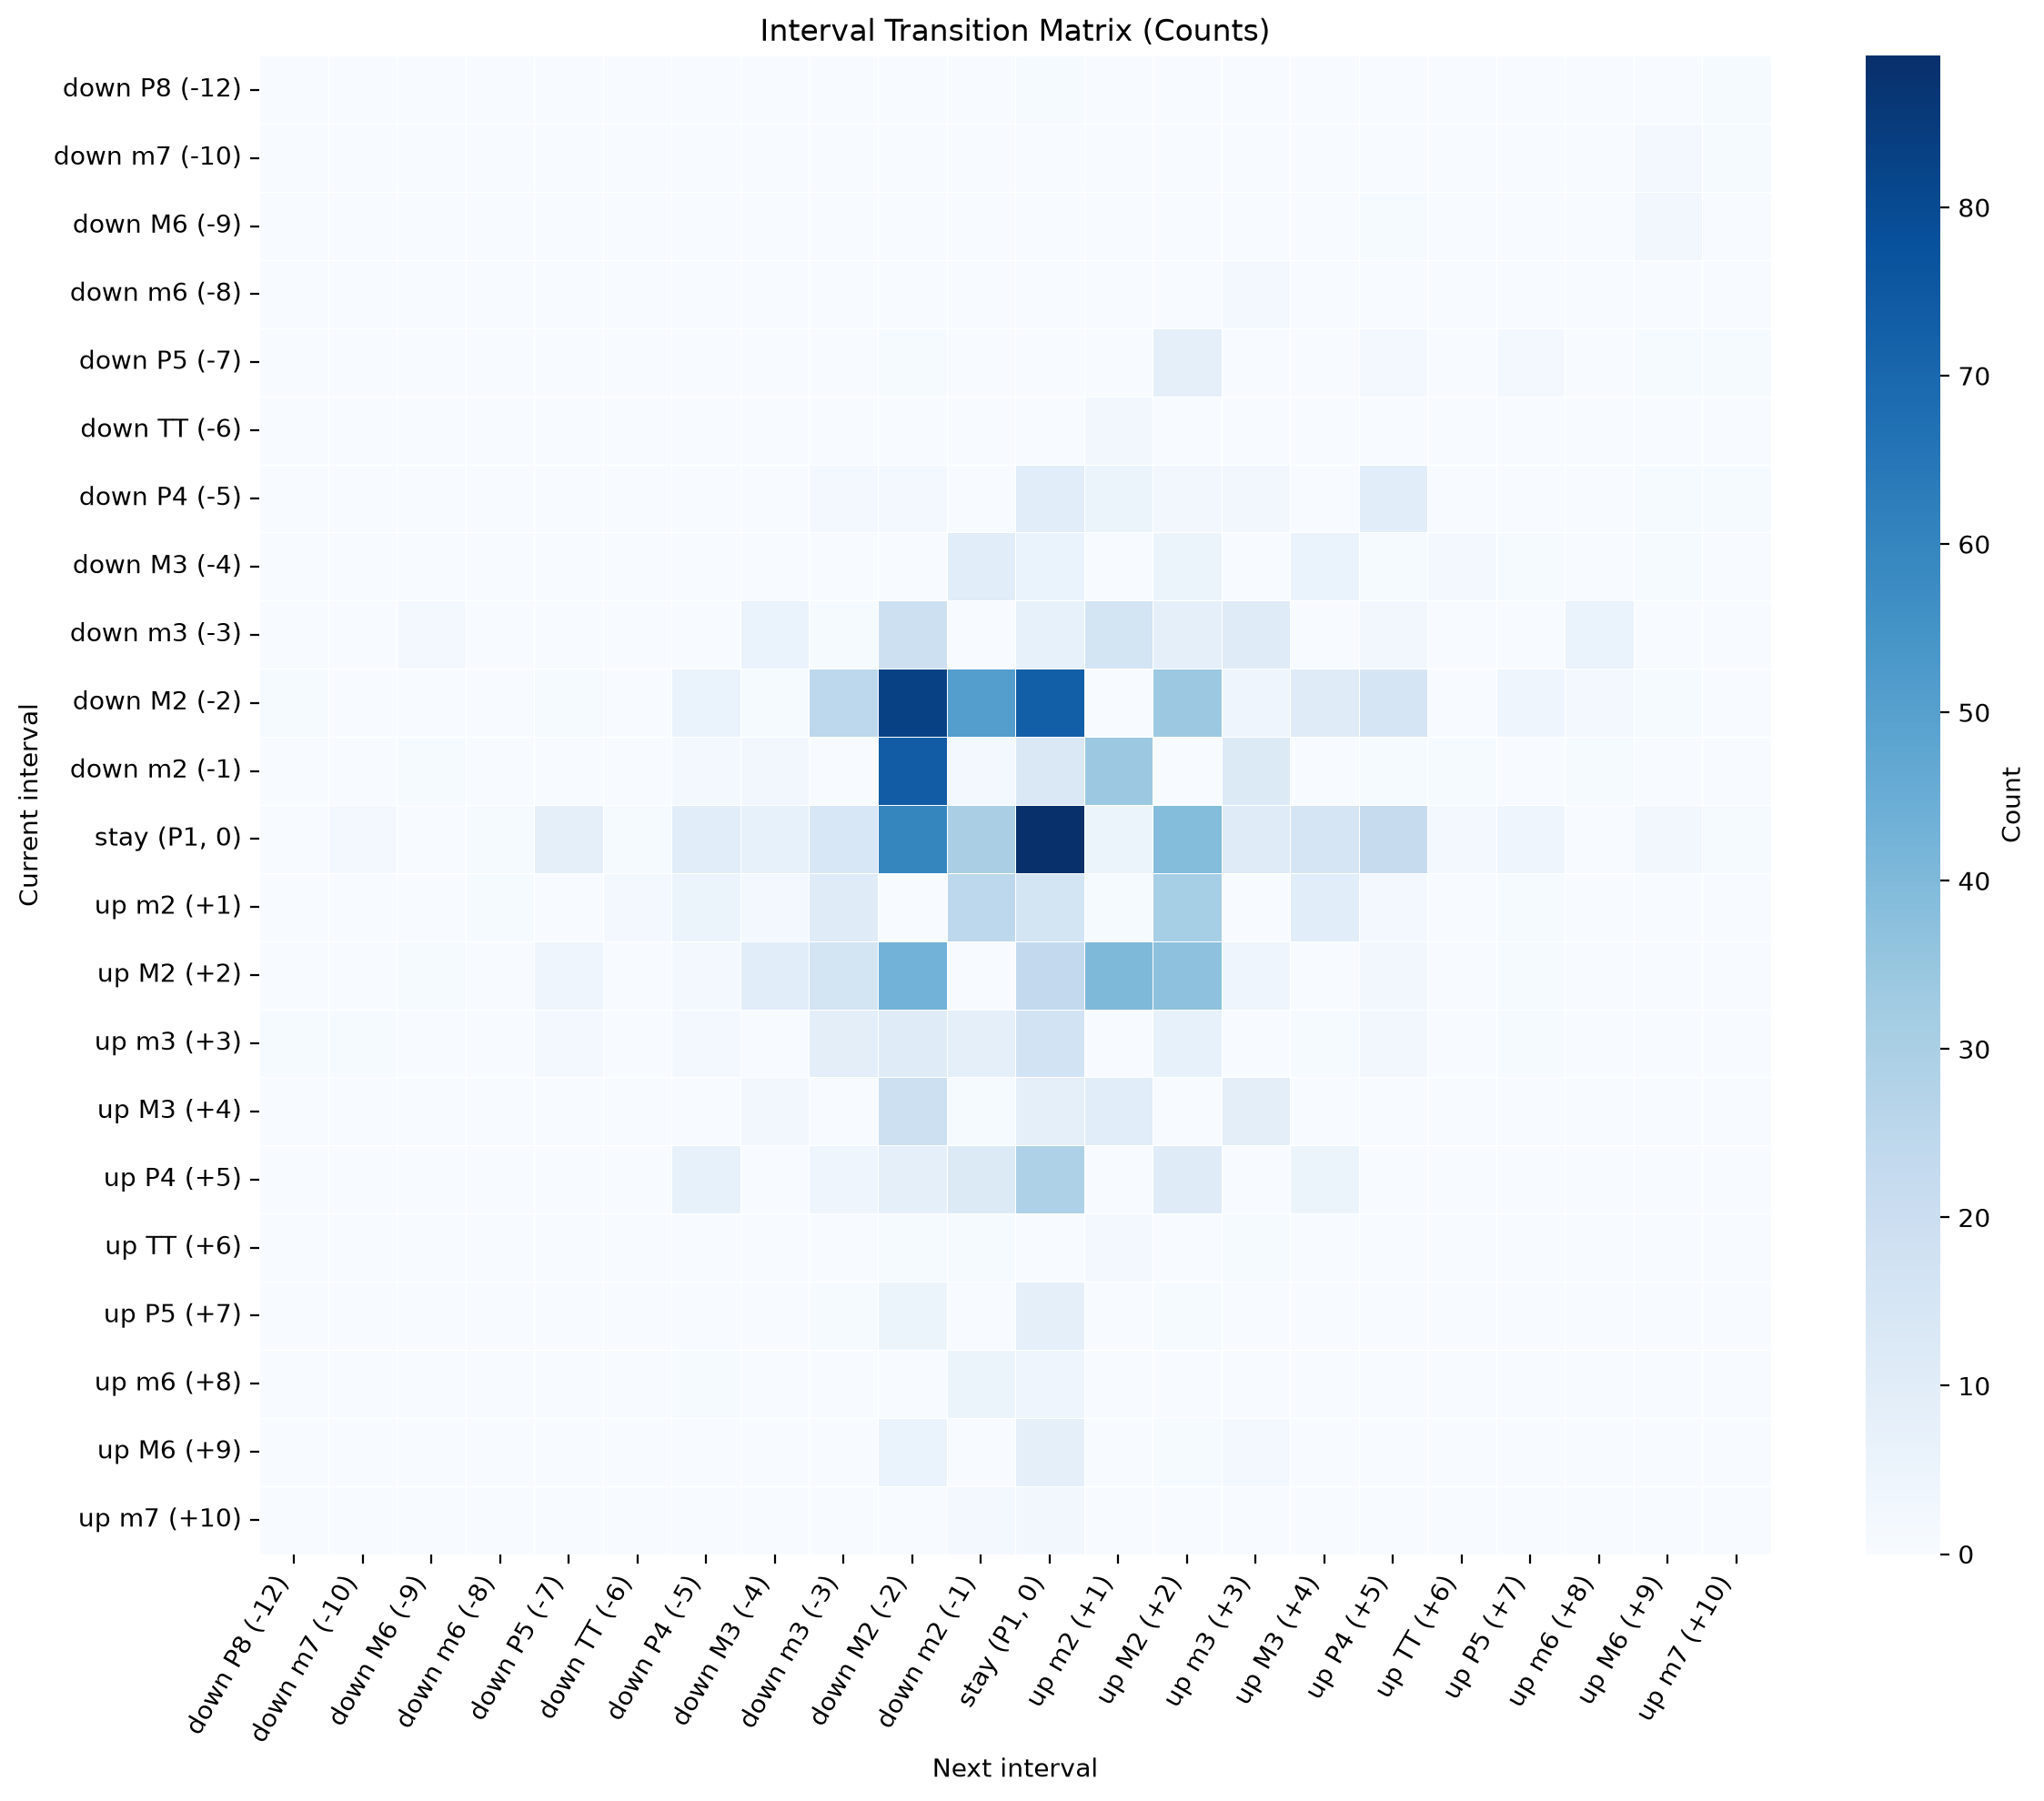

,down P8 (-12),down m7 (-10),down M6 (-9),down m6 (-8),down P5 (-7),down TT (-6),down P4 (-5),down M3 (-4),down m3 (-3),down M2 (-2),...,up m2 (+1),up M2 (+2),up m3 (+3),up M3 (+4),up P4 (+5),up TT (+6),up P5 (+7),up m6 (+8),up M6 (+9),up m7 (+10)
down P8 (-12),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
down m7 (-10),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2,1
down M6 (-9),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,3,0
down m6 (-8),0,0,0,0,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,0,0
down P5 (-7),0,0,0,0,0,0,0,0,0,1,...,0,8,0,0,2,0,2,0,1,1
down TT (-6),0,0,0,0,0,0,0,0,0,0,...,3,0,0,0,0,0,0,0,0,0
down P4 (-5),0,0,0,0,0,0,0,0,2,2,...,5,3,3,0,10,0,0,0,1,1
down M3 (-4),0,0,0,0,0,0,0,0,0,0,...,0,5,0,6,1,2,1,0,1,0
down m3 (-3),0,0,2,0,0,0,0,6,1,19,...,16,8,11,0,3,0,0,6,0,0
down M2 (-2),1,0,0,0,1,0,6,1,25,83,...,0,34,4,11,15,0,4,2,1,0


In [167]:
# Interval transition matrix: names + direction + plot

import matplotlib.pyplot as plt
import seaborn as sns

# Tiny helper: turn a signed semitone number into a readable label.
def interval_label(n):
    interval_names = {
        0: 'P1', 1: 'm2', 2: 'M2', 3: 'm3', 4: 'M3', 5: 'P4',
        6: 'TT', 7: 'P5', 8: 'm6', 9: 'M6', 10: 'm7', 11: 'M7', 12: 'P8'
    }

    if n == 0:
        return 'stay (P1, 0)'

    direction = 'up' if n > 0 else 'down'
    size = abs(int(n))

    if size in interval_names:
        return f"{direction} {interval_names[size]} ({n:+d})"
    return f"{direction} {size} semitones ({n:+d})"


if 'df' not in globals():
    print("Run the data-loading cell first so we have df.")
elif 'intervals' not in df.columns:
    print("I can't find an 'intervals' column in df.")
else:
    # Step 1: grab every consecutive interval pair (a -> b).
    pairs = []
    for interval_list in df['intervals']:
        if interval_list is None or len(interval_list) < 2:
            continue
        for a, b in zip(interval_list, interval_list[1:]):
            pairs.append((int(a), int(b)))

    if len(pairs) == 0:
        print("No interval pairs found.")
    else:
        # Step 2: build a count matrix with raw interval numbers first.
        all_intervals = sorted(set([a for a, _ in pairs] + [b for _, b in pairs]))
        transition_matrix = pd.DataFrame(0, index=all_intervals, columns=all_intervals)

        for a, b in pairs:
            transition_matrix.loc[a, b] += 1

        # Step 3: rename rows/cols so labels are student-friendly.
        label_map = {}
        for n in all_intervals:
            label_map[n] = interval_label(n)

        transition_matrix_named = transition_matrix.rename(index=label_map, columns=label_map)

        # Step 4: show the matrix as a plot.
        plt.figure(figsize=(12, 10))
        sns.heatmap(transition_matrix_named, cmap='Blues', linewidths=0.2, cbar_kws={'label': 'Count'})
        plt.title('Interval Transition Matrix (Counts)')
        plt.xlabel('Next interval')
        plt.ylabel('Current interval')
        plt.xticks(rotation=60, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

        # Also display the DataFrame in case you want to inspect exact numbers.
        display(transition_matrix_named)

## Exercise 4: Scale degrees vs intervals — which makes more sense for your research question?

Pick one Essen region you haven't used yet. Compute both:
- The top-10 scale-degree bigrams
- The top-10 interval bigrams (in semitones)

For a researcher trying to compare melodic style across different regional folk traditions, which 
representation is more useful — scale degrees or intervals? 

Your argument should engage with at least one specific result from 
your analysis (not just a general claim).

## Email to Dan, Day 2!

Please email me with the following:

1. Two melodic corpora compared in terms of transition probabilities (these can be notes, scale degrees, or intervals)
2. You own analytical interpretation of these.


Please make them different corpora than what you already worked with in class!
*(100–150 words)*
